To Check GPU is connected, execute following code

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

from numpy import array
from keras.preprocessing.text import one_hot
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers.core import Activation, Dropout, Dense
from keras.layers import Flatten
from keras.layers import GlobalMaxPooling1D,Conv1D
from keras.layers.embeddings import Embedding
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import Tokenizer



seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
!pip install bnlp_toolkit


     |████████████████████████████████| 1.2MB 38.0MB/s 
     |████████████████████████████████| 23.9MB 54.3MB/s 
     |████████████████████████████████| 747kB 32.8MB/s 
  Found existing installation: gensim 3.6.0
    Uninstalling gensim-3.6.0:
      Successfully uninstalled gensim-3.6.0


In [ ]:
print(tf.keras.__version__)
print(tf.__version__)
!python --version

2.5.0
2.5.0
Python 3.7.10


In [ ]:
movie_reviews = pd.read_excel(r"/content/drive/MyDrive/Musta_csv/Dataset_bookReviews_2000.xlsx")

movie_reviews.isnull().values.any()

movie_reviews.shape

(2011, 3)

In [ ]:
movie_reviews.head()

,Unnamed: 0,Review,Sentiment
0,0,বই টি আমার সংগ্রহে আছে এবং তা আমি পড়েছি। বই টি...,0
1,1,ফালতু বই। শুধু শুধু টাকা নষ্ট।,0
2,2,"একটু পড়ে দেখতে বলসিলো, একটু পড়লাম। তারপর হড়হড় ...",0
3,3,এটা কোন বই? ছিঃ ধিকার জানায়। প্রশাসনের নজর দেয়...,0
4,4,"প্রিয় রকমারি.কম, দয়া করে বইটি আপনাদের ওয়েবসাইট...",0


In [ ]:
#movie_reviews["Text"][3]

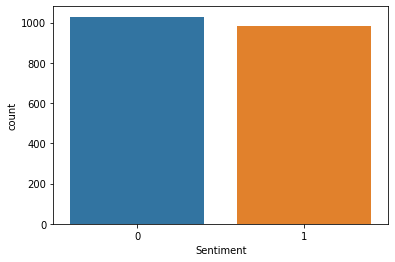

In [ ]:
import seaborn as sns

sns_plot=sns.countplot(x='Sentiment', data=movie_reviews)
fig = sns_plot.get_figure()
fig.savefig("data_shape.png")

In [ ]:
def preprocess_text(sen):
    # Removing html tags
    sentence = remove_tags(sen)
    
    # Removing multiple spaces
    sentence = re.sub(r'\s+', ' ', sentence)

    return sentence

In [ ]:
TAG_RE = re.compile(r'<[^>]+>')

def remove_tags(text):
    return TAG_RE.sub('', text)

In [ ]:
Z=[]
Sent=[]
sentence_tokens_list = []
word_tokens_list = []
pos_tags_list = []
sentences = []

sentence_tokens_list.clear()
word_tokens_list.clear()
pos_tags_list.clear()
sentences.clear()


sentence = list(movie_reviews['Review'])

for sen in sentence:
    sentences.append(preprocess_text(sen))


In [ ]:
print(sentences[:5])

['বই টি আমার সংগ্রহে আছে এবং তা আমি পড়েছি। বই টি সম্পর্কে যদি এক কথায় বলতে হয় তবে বলবো মন্দের ভালো ।', 'ফালতু বই। শুধু শুধু টাকা নষ্ট।', 'একটু পড়ে দেখতে বলসিলো, একটু পড়লাম। তারপর হড়হড় করে বমি করে দিলাম। কেনার সাহস পাই নি। রিভিউতে আর নাই গেলাম। অনেকে রিভিউ দিছে। শুধু এইটুকু বলবো, দিনশেষে এদের রিভিউ দিয়ে থামানো যাবেনা। এরা কেয়ার করে নাকে কি বললো না বললো।', 'এটা কোন বই? ছিঃ ধিকার জানায়। প্রশাসনের নজর দেয়া উচিৎ কোন বই ২১ শে বই মেলায় পাবলিশ হচ্ছে। সেটা কতটা মান সম্পূর্ণ। আর রকমারিরও উচিৎ ছিল, এমন বই তাদের ওয়েবসাইটে পাবলিশ না করা।', 'প্রিয় রকমারি.কম, দয়া করে বইটি আপনাদের ওয়েবসাইট থেকে সরিয়ে ফেলুন। বড্ড বেমানান দেখাচ্ছে এই বাংলিশ বইটিকে।']


In [ ]:
# X.clear()

Z.clear()

Sent.clear()


In [ ]:
import nltk
nltk.download('punkt')
# X.clear()
Z.clear()
local_pos_tags = []
local_pos_tags.clear()
pos_tags_list.clear()

import copy ## to implement shallow copy. See copy in python

from bnlp import NLTKTokenizer
from bnlp import POS
bn_pos = POS()
model_path = "/content/drive/MyDrive/Musta_csv/bn_pos_model.pkl"
for i in range(len(sentences)):
    text = sentences[i]
    bnltk = NLTKTokenizer()
    
    
    word_tokens = bnltk.word_tokenize(text)
    word_tokens_copy = copy.copy(word_tokens)
#     word_tokens_list.append(word_tokens)
    
    
    sentence_tokens = bnltk.sentence_tokenize(text)
    sentence_tokens_list.append(sentence_tokens)
    
    for j in range(len(word_tokens)):
        word = word_tokens[j]    
        pos_tags = bn_pos.tag(model_path, word)
        
        if(pos_tags[0][1] == "PU"):
            word_tokens_copy.remove(str(word))

            
    word_tokens_list.append(word_tokens_copy)

            

print("\n Sentence Tokens")
print(sentence_tokens_list[:3])

print("\n Word Tokens")
print(word_tokens_list[:3])




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


/usr/local/lib/python3.7/dist-packages/gensim/similarities/__init__.py:15: UserWarning: The gensim.similarities.levenshtein submodule is disabled, because the optional Levenshtein package <https://pypi.org/project/python-Levenshtein/> is unavailable. Install Levenhstein (e.g. `pip install python-Levenshtein`) to suppress this warning.
  warnings.warn(msg)



 Sentence Tokens
[['বই টি আমার সংগ্রহে আছে এবং তা আমি পড়েছি।', 'বই টি সম্পর্কে যদি এক কথায় বলতে হয় তবে বলবো মন্দের ভালো ।'], ['ফালতু বই।', 'শুধু শুধু টাকা নষ্ট।'], ['একটু পড়ে দেখতে বলসিলো, একটু পড়লাম।', 'তারপর হড়হড় করে বমি করে দিলাম।', 'কেনার সাহস পাই নি।', 'রিভিউতে আর নাই গেলাম।', 'অনেকে রিভিউ দিছে।', 'শুধু এইটুকু বলবো, দিনশেষে এদের রিভিউ দিয়ে থামানো যাবেনা।', 'এরা কেয়ার করে নাকে কি বললো না বললো।']]

 Word Tokens
[['বই', 'টি', 'আমার', 'সংগ্রহে', 'আছে', 'এবং', 'তা', 'আমি', 'পড়েছি', 'বই', 'টি', 'সম্পর্কে', 'যদি', 'এক', 'কথায়', 'বলতে', 'হয়', 'তবে', 'বলবো', 'মন্দের', 'ভালো'], ['ফালতু', 'বই', 'শুধু', 'শুধু', 'টাকা', 'নষ্ট'], ['একটু', 'পড়ে', 'দেখতে', 'বলসিলো', 'একটু', 'পড়লাম', 'তারপর', 'করে', 'বমি', 'করে', 'দিলাম', 'কেনার', 'সাহস', 'পাই', 'নি', 'রিভিউতে', 'আর', 'নাই', 'গেলাম', 'অনেকে', 'রিভিউ', 'দিছে', 'শুধু', 'বলবো', 'দিনশেষে', 'এদের', 'রিভিউ', 'দিয়ে', 'থামানো', 'যাবেনা', 'এরা', 'কেয়ার', 'করে', 'নাকে', 'কি', 'বললো', 'না', 'বললো']]


In [ ]:
## We are creating word tokens first in 'word_tokens' . Then a shallow copy is made of 'word_tokens' to 
## 'word_tokens_copy'. We then check the POS tag of the tokens and if any one of them is "PU" (i.e punctuation)
## then we remove it from 'word_tokens_copy'. After iterating through all the tokens (hence removing all the "PU")
## we add 'word_tokens_copy' to 'word_tokens_list' .

## All these mess is done to remove the error 'list index out of range' while removing an element

In [ ]:
copy_of_word_tokens_list = [] ## It is costly to compute "word_tokens_list".
                            ## So I'm keeping an copy so that I can experiment with one and change it as wish
copy_of_word_tokens_list.clear()
copy_of_word_tokens_list = copy.copy(word_tokens_list)

In [ ]:
word_tokens_list = copy.copy(copy_of_word_tokens_list)

In [ ]:


remove_counter = 0  ## to check if any array is removed for being empty
token_lngth = 0
token_length = len(word_tokens_list) ## to iterate over the whole "word_tokens_list" array
empty_positions = [] ## keep track of empty positions
empty_positions.clear()
print(token_length) ## How many positions are empty actually 

for i in range(token_length):
    if(len(copy_of_word_tokens_list[i]) == 0):
        word_tokens_list.pop(i)
        empty_positions.append(i)
        remove_counter += 1
        print("a")
        
        
print(remove_counter)

2011
a
a
2


In [ ]:
print(len(word_tokens_list))

print(len(sentence_tokens_list))


2009
2011


In [ ]:

print(len(word_tokens_list))

print(len(sentence_tokens_list))


2009
2011


In [ ]:
#word2vec
import json
import os
import re
import string
import numpy as np

from gensim.models import Word2Vec


In [ ]:
model1 =Word2Vec(word_tokens_list, vector_size=100, window=15, min_count=1,sg=0)
#model2 =Word2Vec.load('bn_w2v_model.text')
model1.wv.save_word2vec_format("/content/drive/MyDrive/Musta_csv/myword2vec_model.txt")

In [ ]:
model1.wv["ভালো"]

array([-0.718746  ,  0.6374961 , -0.38850892,  0.04935136,  0.53143096,
       -1.4712893 ,  0.5373824 ,  2.0584717 , -0.6365732 , -0.33101937,
       -0.51198566, -1.2629769 , -0.30102772,  0.27196443, -0.1948766 ,
       -1.3345196 , -0.28444812, -0.7937664 ,  0.38978648, -1.9649419 ,
        0.5158739 , -0.05169306,  0.6429649 , -0.89287305, -0.16836266,
       -0.6748082 , -0.62884486, -0.441689  , -0.8677899 , -0.75323623,
        0.72570276, -0.2622045 ,  0.83641064, -0.9957286 , -0.33363143,
        1.3020526 ,  0.26538083, -0.5152328 , -0.38488   , -1.5172251 ,
        0.29265556, -0.59133196, -0.64294046,  0.07840357,  1.2479968 ,
       -0.41611734, -0.4740759 , -0.35579818,  1.1524135 ,  0.61171925,
        1.294601  , -0.5856706 ,  0.48129985, -0.4508846 , -0.15549806,
        0.56199205,  0.7163705 ,  0.36960718, -0.7358039 ,  0.74958545,
        0.68922764,  0.2412007 , -0.2955407 ,  0.0845892 , -0.61191976,
        0.95103   , -0.15145501,  0.42449594, -1.6152129 ,  1.60

In [ ]:
y = movie_reviews['Sentiment']

print(len(y))


2011


In [ ]:

for i in range(len(empty_positions)):
    y.pop(empty_positions[i])

print(len(y))


2009


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(word_tokens_list, y, test_size=0.10, random_state=42)

print(X_train[:5])
print(y_train[:5])

[['বইটি', 'খুবই', 'তথ্য', 'বহুল', 'ও', 'সময়োপযোগী', 'আমার', 'খুবই', 'ভালো', 'লেগেছে'], ['অপেক্ষা', 'একটি', 'নিন্ম', 'মানের', 'উপন্যাস', 'অনেকটা', 'ইন্ডিয়ান', 'বাংলা', 'সিরিয়াল', 'এর', 'মত', 'ছোট', 'একটি', 'সংলাপ', 'কে', 'টেনে', 'হিছড়ে', 'লম্বা', 'করা', 'হয়েছে', 'তাও', 'খুব', 'বাজে', 'ভাবে', 'এর', 'ফোন', 'অালাপ', 'এ', 'না', 'হতো', 'এটা', 'বেশি', 'হয়ে', 'গেছে', 'খুবই', 'কাচা', 'লেখা', 'এটা', 'যে', 'লেখক', 'এর', 'উপন্যাস', 'সেটা', 'তার', 'লেখাতে', 'স্পষ্ট', 'অার', 'অনেক', 'জায়গায়', 'অসংগতি', 'রয়েছে', 'সব', 'মিলিয়ে', 'অপেক্ষা', 'অামার', 'শুধু', 'অাক্ষেপ', 'ই', 'বাড়িয়েছে'], ['এই', 'বই', 'কোনো', 'মেয়েই', 'পড়তে', 'স্বাচ্ছন্দ্য', 'বোধ', 'করবে', 'না', 'কোনো', 'মেয়েই', 'তার', 'পরিচিত', 'মানুষজনদের', 'বলতে', 'পারবে', 'না', 'যে', 'এই', 'বইটি', 'পড়ুন', 'অশ্লীল', 'নোংরা', 'ও', 'ফালতু', 'একটা', 'বই'], ['দক্ষতা', 'আর', 'অভিজ্ঞতা', 'দুইটা', 'ভিন্ন', 'জিনিস', 'দুইটাকে', 'আপনি', 'যখন', 'সমান', 'তালে', 'কাজে', 'লাগাতে', 'পারবেন', 'তখনই', 'আপনি', 'একজন', 'সাধারণ', 'জীবন', 'থেকে', 'অসাধারণ', 'জীবন', 'লাভের'

In [ ]:
print(len(X_train))

len(X_test)

1808


201

In [ ]:

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [ ]:

X_train[:5]

[[5, 41, 211, 1163, 37, 1164, 9, 41, 11, 51],
 [330,
  6,
  3058,
  411,
  96,
  508,
  1920,
  103,
  1433,
  20,
  82,
  153,
  6,
  3059,
  91,
  743,
  3060,
  1921,
  35,
  34,
  848,
  15,
  108,
  134,
  20,
  970,
  3061,
  63,
  4,
  467,
  69,
  62,
  97,
  178,
  41,
  1922,
  33,
  69,
  18,
  36,
  20,
  96,
  157,
  29,
  1923,
  1924,
  1925,
  13,
  331,
  3062,
  246,
  60,
  468,
  330,
  1434,
  135,
  3063,
  239,
  1926],
 [2,
  1,
  143,
  1927,
  77,
  3064,
  655,
  136,
  4,
  143,
  1927,
  29,
  1928,
  3065,
  106,
  602,
  4,
  18,
  2,
  5,
  1165,
  1166,
  849,
  37,
  137,
  16,
  1],
 [1435,
  17,
  549,
  971,
  972,
  438,
  1929,
  98,
  162,
  3066,
  3067,
  247,
  1930,
  353,
  1167,
  98,
  101,
  313,
  248,
  28,
  25,
  248,
  1168,
  3068,
  3069,
  2,
  1929,
  40,
  134,
  3070,
  8,
  439,
  229,
  157,
  256,
  3071,
  850,
  1931,
  104,
  41,
  40,
  134,
  509,
  603,
  1932,
  15,
  412,
  365,
  35,
  354,
  5,
  138,
  3,
  41,
  

In [ ]:
vocab_size = len(tokenizer.word_index) + 1

# print(vocab_size)

maxlen = 100

X_train = pad_sequences(X_train, padding='post', maxlen=maxlen)
X_test = pad_sequences(X_test, padding='post', maxlen=maxlen)

In [ ]:
X_train[:5]

array([[   5,   41,  211, 1163,   37, 1164,    9,   41,   11,   51,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0],
       [ 330,    6, 3058,  411,   96,  508, 1920,  103, 1433,   20,   82,
         153,    6, 3059,   91,  743, 3060, 1921,   35,   34,  848,   15,
         108,  134,   20,  970, 3061,   63,    4,  467,   69,   62,   97,
         178,   41, 1922,   33,   69,   18,   36,   20,   96,  157,   29,
        1923, 1924, 192

In [ ]:
from numpy import array
from numpy import asarray
from numpy import zeros

embeddings_dictionary = dict()
glove_file = open('/content/drive/MyDrive/Musta_csv/myword2vec_model.txt', encoding="utf8")

for line in glove_file:
    records = line.split()
    word = records[0]
    vector_dimensions = asarray(records[1:], dtype='float32')

    embeddings_dictionary [word] = vector_dimensions
glove_file.close()


embedding_matrix = zeros((vocab_size, 100))
for word, index in tokenizer.word_index.items():

    embedding_vector = embeddings_dictionary.get(word)

    if embedding_vector is not None:
        embedding_matrix[index] = embedding_vector


In [ ]:
embedding_matrix[10]


array([-0.73199421,  0.70608389, -0.37529865,  0.03745055,  0.5549739 ,
       -1.57562089,  0.59133303,  2.21603703, -0.69224334, -0.35064179,
       -0.54559147, -1.36999369, -0.28739345,  0.28083587, -0.19570909,
       -1.46572387, -0.28763598, -0.84865797,  0.41182932, -2.11441827,
        0.54020488, -0.07436218,  0.70358759, -0.95234084, -0.21774185,
       -0.70331138, -0.65712571, -0.50410312, -0.92655057, -0.79502362,
        0.76310408, -0.29485989,  0.89425838, -1.05500686, -0.34701514,
        1.39820552,  0.28084961, -0.57832217, -0.4239859 , -1.63817394,
        0.30357265, -0.63811994, -0.69897932,  0.09425773,  1.33073735,
       -0.4455587 , -0.51378328, -0.39394671,  1.19844127,  0.63895345,
        1.36096466, -0.64849532,  0.47830135, -0.51157117, -0.16905105,
        0.59765935,  0.75114709,  0.38729858, -0.79827517,  0.7921412 ,
        0.71333534,  0.22873497, -0.32965904,  0.08454565, -0.66372168,
        1.02532482, -0.16416188,  0.45602319, -1.74141192,  1.72

In [ ]:
from keras import Sequential, optimizers
from keras.layers import Embedding, LSTM, Dense, Dropout,Bidirectional,ConvLSTM2D,GRU,SimpleRNN,RNN
from keras import regularizers

model2 = Sequential()
embedding_layer = Embedding(vocab_size, 100,weights=[embedding_matrix], input_length=maxlen , trainable=True)
model2.add(embedding_layer)

model2.add (Bidirectional(LSTM(128,  return_sequences=True,kernel_regularizer=regularizers.l2(0.15))))

model2.add(Conv1D(32, 4, activation='relu'))
model2.add (GRU(32,return_sequences=True, activation = 'tanh') )

model2.add(Conv1D(16, 4, activation='relu'))

model2.add(GlobalMaxPooling1D())

model2.add (Dropout(0.4))

model2.add(Dense(16,activation='relu'))


model2.add(Dense(1, activation='sigmoid'))


opt = optimizers.Adam(learning_rate=0.0001)
#lr=0.0005
model2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['acc'])



In [ ]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 100, 100)          818500    
_________________________________________________________________
bidirectional_1 (Bidirection (None, 100, 256)          234496    
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 97, 32)            32800     
_________________________________________________________________
gru_1 (GRU)                  (None, 97, 32)            6336      
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 94, 16)            2064      
_________________________________________________________________
global_max_pooling1d_1 (Glob (None, 16)                0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 16)               

In [ ]:
history = model2.fit(X_train, y_train, batch_size=64, epochs=100, verbose=1, validation_split=0.10)

score = model2.evaluate(X_test, y_test, verbose=1)

Epoch 1/100
26/26 [==============================] - 12s 481ms/step - loss: 0.4900 - acc: 0.9908 - val_loss: 0.9124 - val_acc: 0.9116
Epoch 2/100
26/26 [==============================] - 12s 478ms/step - loss: 0.4860 - acc: 0.9920 - val_loss: 0.8493 - val_acc: 0.9282
Epoch 3/100
26/26 [==============================] - 12s 477ms/step - loss: 0.4647 - acc: 0.9945 - val_loss: 0.8536 - val_acc: 0.9282
Epoch 4/100
26/26 [==============================] - 12s 480ms/step - loss: 0.4590 - acc: 0.9951 - val_loss: 0.9163 - val_acc: 0.9227
Epoch 5/100
26/26 [==============================] - 13s 482ms/step - loss: 0.4675 - acc: 0.9926 - val_loss: 0.9949 - val_acc: 0.8950
Epoch 6/100
26/26 [==============================] - 12s 478ms/step - loss: 0.4551 - acc: 0.9957 - val_loss: 0.9235 - val_acc: 0.9171
Epoch 7/100
26/26 [==============================] - 12s 479ms/step - loss: 0.4553 - acc: 0.9932 - val_loss: 0.9212 - val_acc: 0.9171
Epoch 8/100
26/26 [==============================] - 12s 479ms

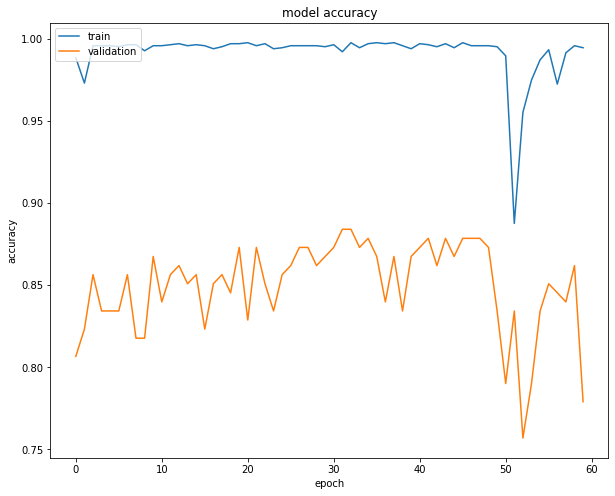

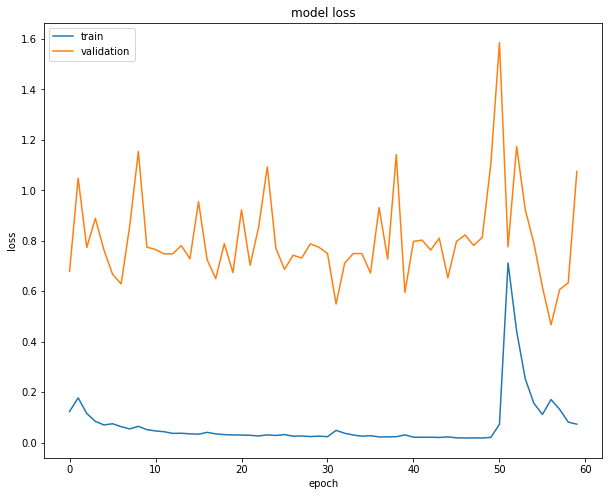

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','validation'], loc = 'upper left')
plt.savefig('/content/drive/MyDrive/Musta_csv/model_Accuracy.png', dpi=600)

plt.show()


plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','validation'], loc = 'upper left')
plt.savefig('/content/drive/MyDrive/Musta_csv/model_loss.png', dpi=600)

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve,roc_auc_score



yhat_classes = model2.predict_classes(X_test, verbose=1)
yhat_classes = yhat_classes[:, 0]
accuracy = accuracy_score(y_test, yhat_classes)

# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, yhat_classes)
print('Accuracy: %f' % accuracy)



# precision tp / (tp + fp)
precision = precision_score(y_test, yhat_classes)
print('Precision: %f' % precision)


# recall: tp / (tp + fn)
recall = recall_score(y_test, yhat_classes)
print('Recall: %f' % recall)



# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, yhat_classes)
print('F1 score: %f' % f1)


# confusion matrix
matrix = confusion_matrix(y_test, yhat_classes)
print(matrix)



3/7 [===========>..................] - ETA: 0s

/usr/local/lib/python3.7/dist-packages/keras/engine/sequential.py:450: UserWarning: `model.predict_classes()` is deprecated and will be removed after 2021-01-01. Please use instead:* `np.argmax(model.predict(x), axis=-1)`,   if your model does multi-class classification   (e.g. if it uses a `softmax` last-layer activation).* `(model.predict(x) > 0.5).astype("int32")`,   if your model does binary classification   (e.g. if it uses a `sigmoid` last-layer activation).
  warnings.warn('`model.predict_classes()` is deprecated and '


7/7 [==============================] - 0s 48ms/step
Accuracy: 0.850746
Precision: 0.939024
Recall: 0.754902
F1 score: 0.836957
[[94  5]
 [25 77]]


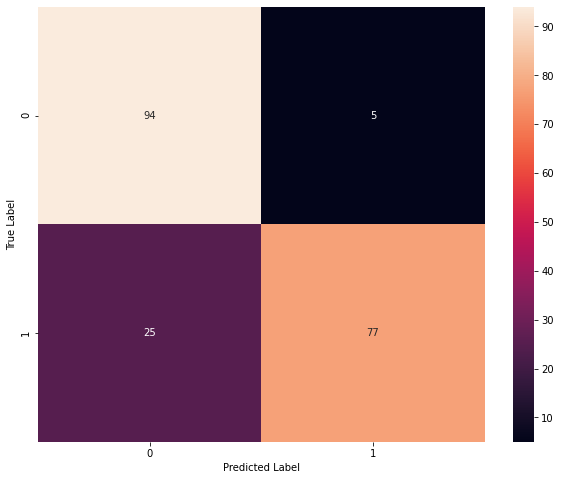

In [ ]:
# confusion_mtx = tf.math.confusion_matrix(y_true, y_pred) 
plt.figure(figsize=(10, 8))
sns.heatmap(matrix, xticklabels='01', yticklabels='01', annot=True, fmt='g')


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('confussion_matrix.png')

plt.show()

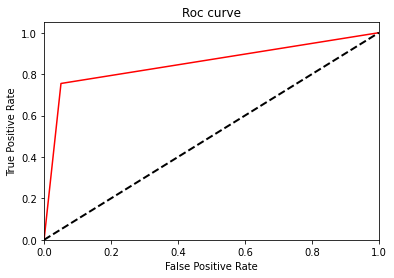

In [ ]:
fpr, tpr, _ = roc_curve(y_test,yhat_classes)
# plt.figure(figsize=(14,8))
plt.plot(fpr, tpr, color="red")
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Roc curve')
plt.savefig('/content/drive/MyDrive/Musta_csv/roc_curve.png', dpi=600)

plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
